In [12]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from AIce.functions import torchRMSE,trainloader,redim,getRMSE,testloader
from  AIce.models import uv256NN
from AIce.plotting import ResidualOnTheMap,PredAgainstTarget
from time import strftime

In [2]:
device = torch.device(torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else 'cpu')
inputlist=['u_ERA5','v_ERA5','h_piomas','sic_CDR','bath']

# Hyperparameters
lr=1e-3
n_epoch=20
print('Total Epoch: ', n_epoch)
print('Learning Rate: ', lr)

data,_,dataloader,means,stds,maxes,labels=trainloader('../data/DRIFT_DATA_TRAIN.csv',256,inputlist,target='u/v')

print(labels)
print('aaa')
print(labels[1])

mlp256=uv256NN(len(labels[1])).to(device)
print('Total Epoch: ', n_epoch)
print('Learning Rate: ', lr)
print(labels)

rlosses={}
losses=[]
rloss=0
rcount=0

optimizer = optim.Adam(mlp256.parameters(),lr=lr) # optimizers

for epoch in range(n_epoch):
    print('Starting Epoch ',epoch)
    curpercent=0
    rl=[]
    for i,data in enumerate(dataloader):

        # get the inputs and the target
        truth,inputs= data[0].to(device),data[1].to(device)

        # zero the gradients,
        optimizer.zero_grad()

        # Forward,
        out=mlp256(inputs)


        loss = torchRMSE(target=truth, outputs=out)
        # Backward
        loss.backward()
        losses.append(loss.item())
        # Optimize

        optimizer.step()

        rloss+= loss.item()
        rcount +=1
        #print where we at plus the loss
        percent= round(i/len(dataloader)*100)
        if percent != curpercent:
        #    print(percent, 'loss: ', rloss/rcount)
            curpercent=percent
            rl.append(rloss/rcount)
            rloss=0
            rcount=0
    rlosses[epoch]=rl
    print('Epoch avg loss: ', np.mean(rl))

saving_name=f'UV_{len(labels[1])}inputs_{n_epoch}E_{lr}lr_{strftime("%d-%Hh_%Mm_%Ss")}'

torch.save(mlp256.state_dict(), f'.//weights//{saving_name}.pt')

with open(f'.//weights//{saving_name}.txt','w') as f:
    f.write(f'Model: NNforNorms (on gpu)\n')
    f.write(f'Weights: {saving_name}.pt\n')
    f.write(f'Associated inputs: {inputlist}')

fig,ax =plt.subplots()
epochavg=[]

for i in (rlosses):
    x=np.arange(i*len(rlosses[0]),len(rlosses[0])+i*len(rlosses[0]))
    ax.plot(x,rlosses[i])#,label=f'Epoch {i+1}, lr={lr[i]:.1e}')
    avg=np.mean(rlosses[i])
    epochavg.append(avg)
xx=[i*len(rlosses[0]) for i in rlosses]
ax.plot(xx,epochavg,'.-k')
plt.savefig(f'.//outputs//loss_for_{saving_name}.png')
plt.close('all')


Total Epoch:  20
Learning Rate:  0.001
Target is u/v components of the wind normalized by z-score
Bathymetry (bath) normalized by maximum
Wind components (u/v_ERA5) normalized by z-score
[Index(['u_buoy', 'v_buoy'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'bath'], dtype='object')]
aaa
Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'bath'], dtype='object')
Total Epoch:  20
Learning Rate:  0.001
[Index(['u_buoy', 'v_buoy'], dtype='object'), Index(['u_ERA5', 'v_ERA5', 'sic_CDR', 'h_piomas', 'bath'], dtype='object')]
Starting Epoch  0
Epoch avg loss:  0.621713156103269
Starting Epoch  1
Epoch avg loss:  0.6094982683347476
Starting Epoch  2
Epoch avg loss:  0.606222683784071
Starting Epoch  3
Epoch avg loss:  0.6031260372567308
Starting Epoch  4
Epoch avg loss:  0.6000225728995853
Starting Epoch  5
Epoch avg loss:  0.5989128509212981
Starting Epoch  6
Epoch avg loss:  0.5973118256883961
Starting Epoch  7
Epoch avg loss:  0.5961836838018109
Starting Epoch  8


KeyboardInterrupt: 

Bath size is the full test set
Target is u/v components of the wind normalized by z-score
Sin and Cos added
Bathymetry (bath) normalized by maximum
x/y (x_EASE, y_EASE) normalized by maximum
Windnorm normalized by z-score
Wind components (u/v_ERA5) normalized by z-score
Bath size is the full test set
Target is u/v components of the wind normalized by z-score
Bathymetry (bath) normalized by maximum
Wind components (u/v_ERA5) normalized by z-score
u Rmse:  4.741733343284721 v RMSE:  4.609028438089419


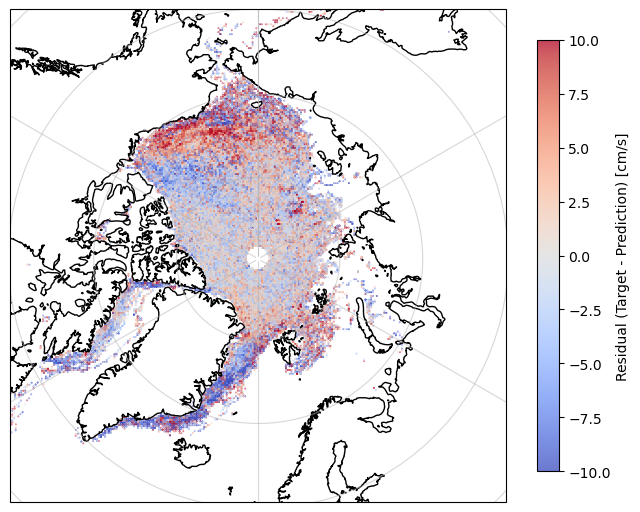

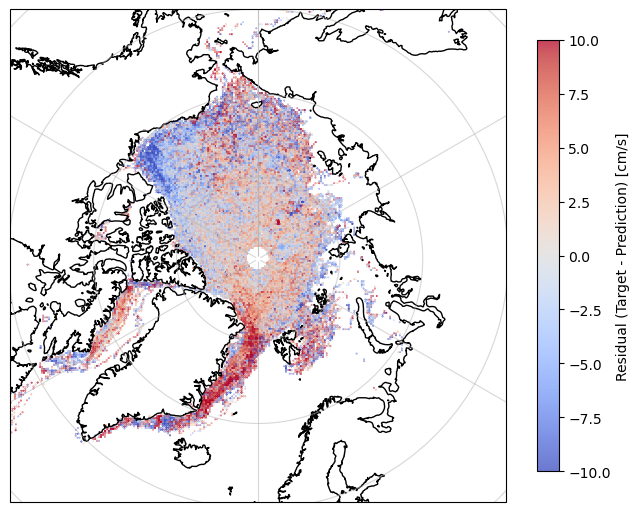

In [13]:
device='cuda'
allinput=['u_ERA5','v_ERA5','h_piomas','sic_CDR','x_EASE','y_EASE','bath','sin','cos', 'windnorm']
lst=['u_ERA5', 'v_ERA5', 'h_piomas', 'sic_CDR', 'bath']
weightpath='./weights/UV_5inputs_20E_0.001lr_18-13h_37m_54s.pt'

testdata,_,_,means,stds,maxes,labels=testloader('../data/DRIFT_DATA_FULL.csv',inputlist=allinput ,target='u/v',
                                trainingset_loaded=False, training_file='../data/DRIFT_DATA_TRAIN.csv')# Get the means,stds,maxes using the longest list possible

modeldata,_,_,_,_,_,_=testloader('../data/DRIFT_DATA_FULL.csv',inputlist=lst ,target='u/v',
                                trainingset_loaded=True, means=means,stds=stds,maxes=maxes)# Get the means,stds,maxes using the longest list possible

mlp256= uv256NN(len(lst)).to(device) # Creates a model for the specific n_inputs
mlp256.load_state_dict(torch.load(weightpath, weights_only=True))# loads the weights onto the model
mlp256.eval()  # if you're doing inference, not continuing training

out=mlp256(torch.tensor(modeldata.drop(['u_buoy','v_buoy'], axis=1).values, dtype= torch.float32).to(device)).to('cpu').detach().numpy().T# runs the data into the model 
testdata=redim(testdata,
               means=means,
               stds=stds,
               maxes=maxes)
testdata['u_out']=(out[0]*stds['u_buoy'])+means['u_buoy'] # save the model prediction in the datapd with name associated to n_inputs
testdata['v_out']=(out[1]*stds['v_buoy'])+means['v_buoy']

# DATA IS DIMENSONALIZED
u_rmse=getRMSE(testdata['u_buoy'].values, testdata['u_out'].values)
v_rmse=getRMSE(testdata['v_buoy'].values, testdata['v_out'].values)
testdata['buoynorm']=np.sqrt(testdata['u_buoy']**2+testdata['v_buoy']**2)
print('u Rmse: ', u_rmse, 'v RMSE: ', v_rmse)


# PredAgainstTarget(testdata['buoynorm'], testdata['output'], testdata['windnorm'])
ResidualOnTheMap(testdata,'u_out', 'u_buoy')
ResidualOnTheMap(testdata,'v_out', 'v_buoy')

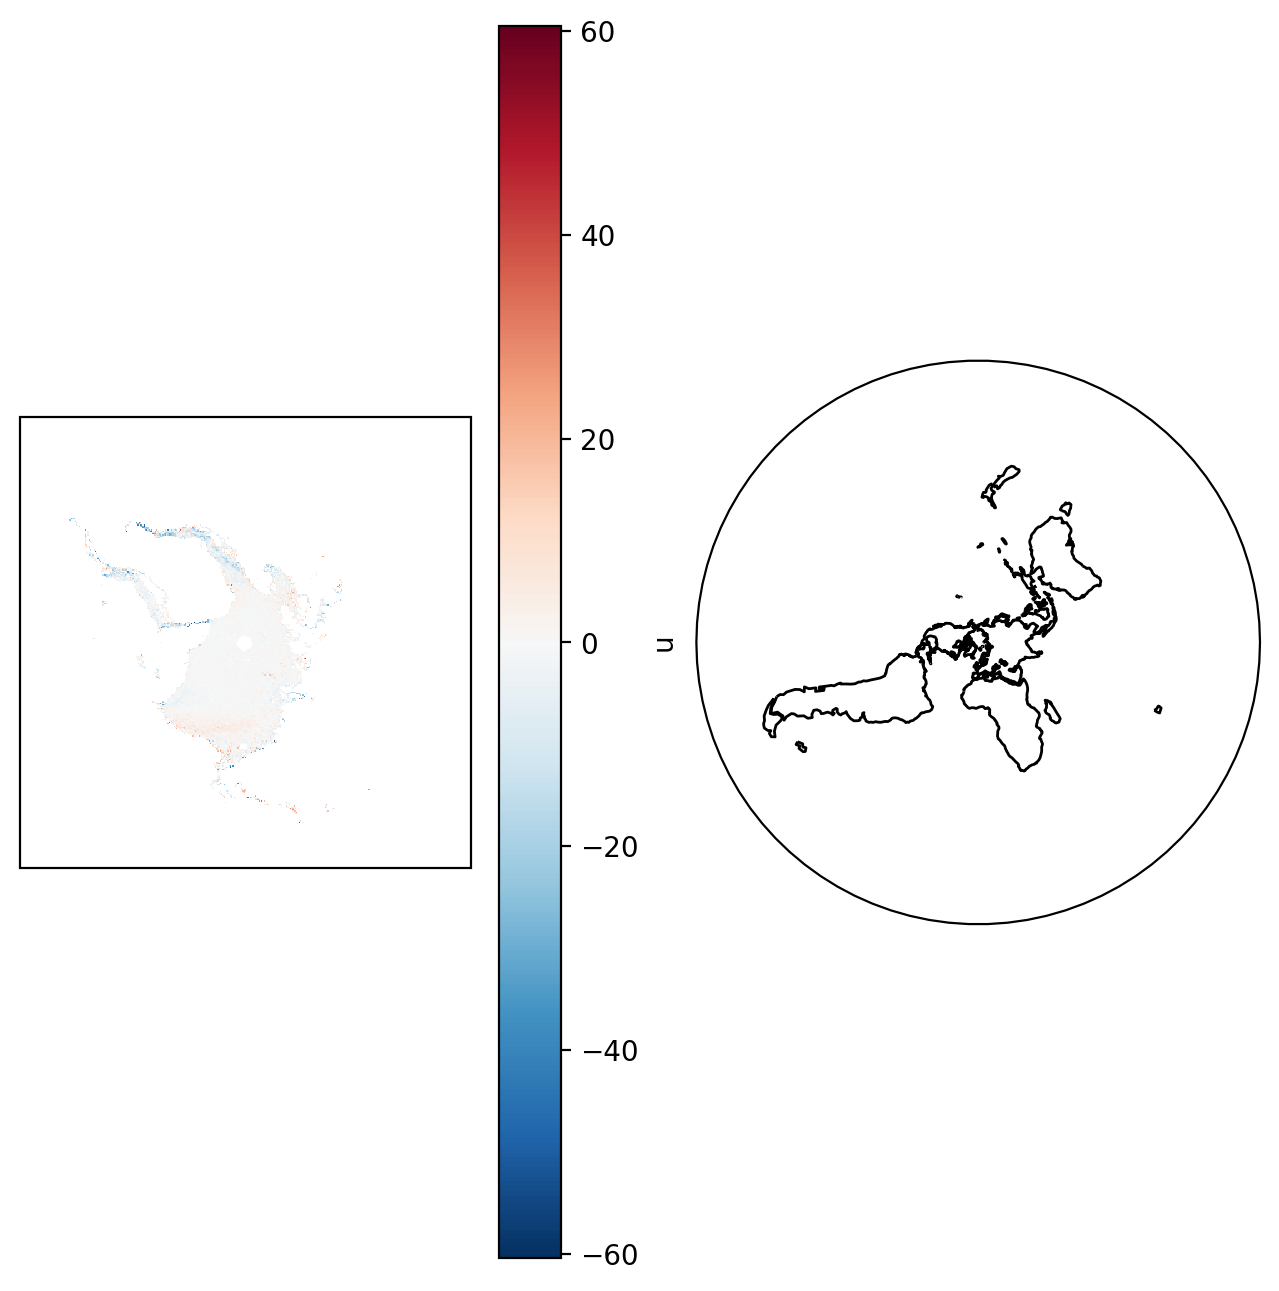

In [14]:
import numpy as np
import pandas as pd
import xarray as xr

lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

ures=testdata['u_buoy'].values - testdata['u_out'].values
vres=testdata['v_buoy'].values - testdata['v_out'].values


ny, nx = lat_grid.shape

y_idx = testdata['y_EASE'].astype(int).values
x_idx = testdata['x_EASE'].astype(int).values

df = pd.DataFrame({'y': y_idx, 'x': x_idx, 'u': ures, 'v': -vres})
grouped = df.groupby(['y', 'x']).mean()

u_grid = np.full((ny, nx), np.nan)
v_grid = np.full((ny, nx), np.nan)
u_grid[grouped.index.get_level_values('y'), grouped.index.get_level_values('x')] = grouped['u'].values
v_grid[grouped.index.get_level_values('y'), grouped.index.get_level_values('x')] = grouped['v'].values

uwater = xr.Dataset(
    {
        'u': (['y', 'x'], u_grid),
        'v': (['y', 'x'], v_grid),
    },
    coords={
        'y': np.arange(ny),
        'x': np.arange(nx),
        'lat': (['y', 'x'], lat_grid),
        'lon': (['y', 'x'], lon_grid),
    }
)

from matplotlib.colors import Normalize
import cartopy.crs as ccrs 

fig, ax = plt.subplots(
    1,2,
    figsize=(8, 8),
    dpi=200,
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

#vmin,vmax=0,10
#norm = Normalize(vmin, vmax)
cmap = 'plasma'
for i in range(2):
    ax[i].coastlines()


uwater['u'].plot(ax=ax[0],transform= ccrs.NorthPolarStereo() )

# back= ax[0].scatter(
#     lons, lats,
#         c=testdata['u_geo'], cmap=cmap, #norm=norm,
#         transform=ccrs.PlateCarree(),
#         s=.1
# )
# plt.colorbar(back, ax=ax, label='Residual (Target - Prediction) [cm/s]', shrink=0.7)

# b= ax[1].scatter(
#     lons, lats,
#         c=testdata['v_geo'], cmap=cmap, #norm=norm,
#         transform=ccrs.PlateCarree(),
#         s=.1
# )
# plt.colorbar(b, ax=ax, label='Residual (Target - Prediction) [cm/s]', shrink=0.7)

In [15]:
import numpy as np
from scipy.spatial import cKDTree
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

ures=testdata['u_buoy'].values - testdata['u_out'].values
vres=testdata['v_buoy'].values - testdata['v_out'].values
# use the *continuous* coordinates, not the rounded integer indices
# x = testdata['x_EASE'].values
# y = testdata['y_EASE'].values
u = ures
v = vres

coords = np.column_stack([testdata['x_EASE'].values, testdata['y_EASE'].values])

# THIS IS FROM CLAUDE I WAS NOT SURE HOW TO TAKE AVERAGE OVER CLOUD OF POINTS RATHER THAN GRID

tree = cKDTree(coords)

K = 50            # number of neighbors to consider
bandwidth = 2   # smoothing length scale, in EASE grid units (~25 km/unit typically)

dist, idx = tree.query(coords, k=K)   # vectorized: (N, K) arrays

weights = np.exp(-0.5 * (dist / bandwidth) ** 2)
weights /= weights.sum(axis=1, keepdims=True)

u_smooth = np.sum(weights * u[idx], axis=1)
v_smooth = np.sum(weights * v[idx], axis=1)

testdata['u_geo'] = u_smooth
testdata['v_geo'] = v_smooth

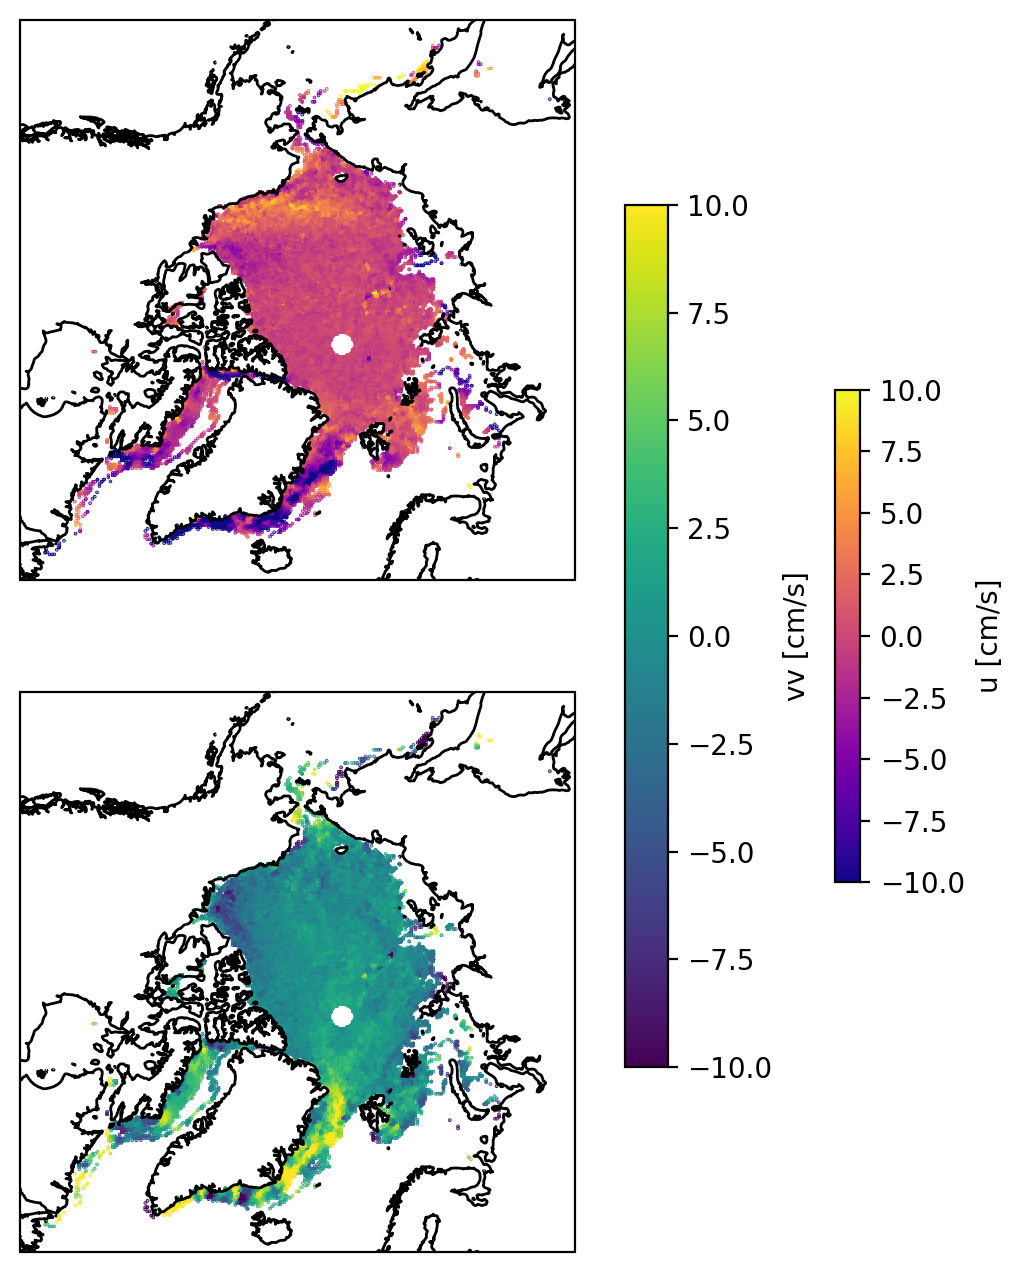

In [16]:
from matplotlib.colors import Normalize
import cartopy.crs as ccrs 

fig, ax = plt.subplots(
    2,1,
    figsize=(8, 8),
    dpi=200,
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

vmin,vmax=-10,10
norm = Normalize(vmin, vmax)
cmap = 'plasma'
for i in range(2):
    ax[i].coastlines()


back= ax[0].scatter(
    lons, lats,
        c=testdata['u_geo'], cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        s=.1
)
plt.colorbar(back, ax=ax, label='u [cm/s]', shrink=0.4)

b= ax[1].scatter(
    lons.T, lats.T,
        c=testdata['v_geo'].T, cmap='viridis', norm=norm,
        transform=ccrs.PlateCarree(),
        s=.1
)
plt.colorbar(b, ax=ax, label='vv [cm/s]', shrink=0.7)

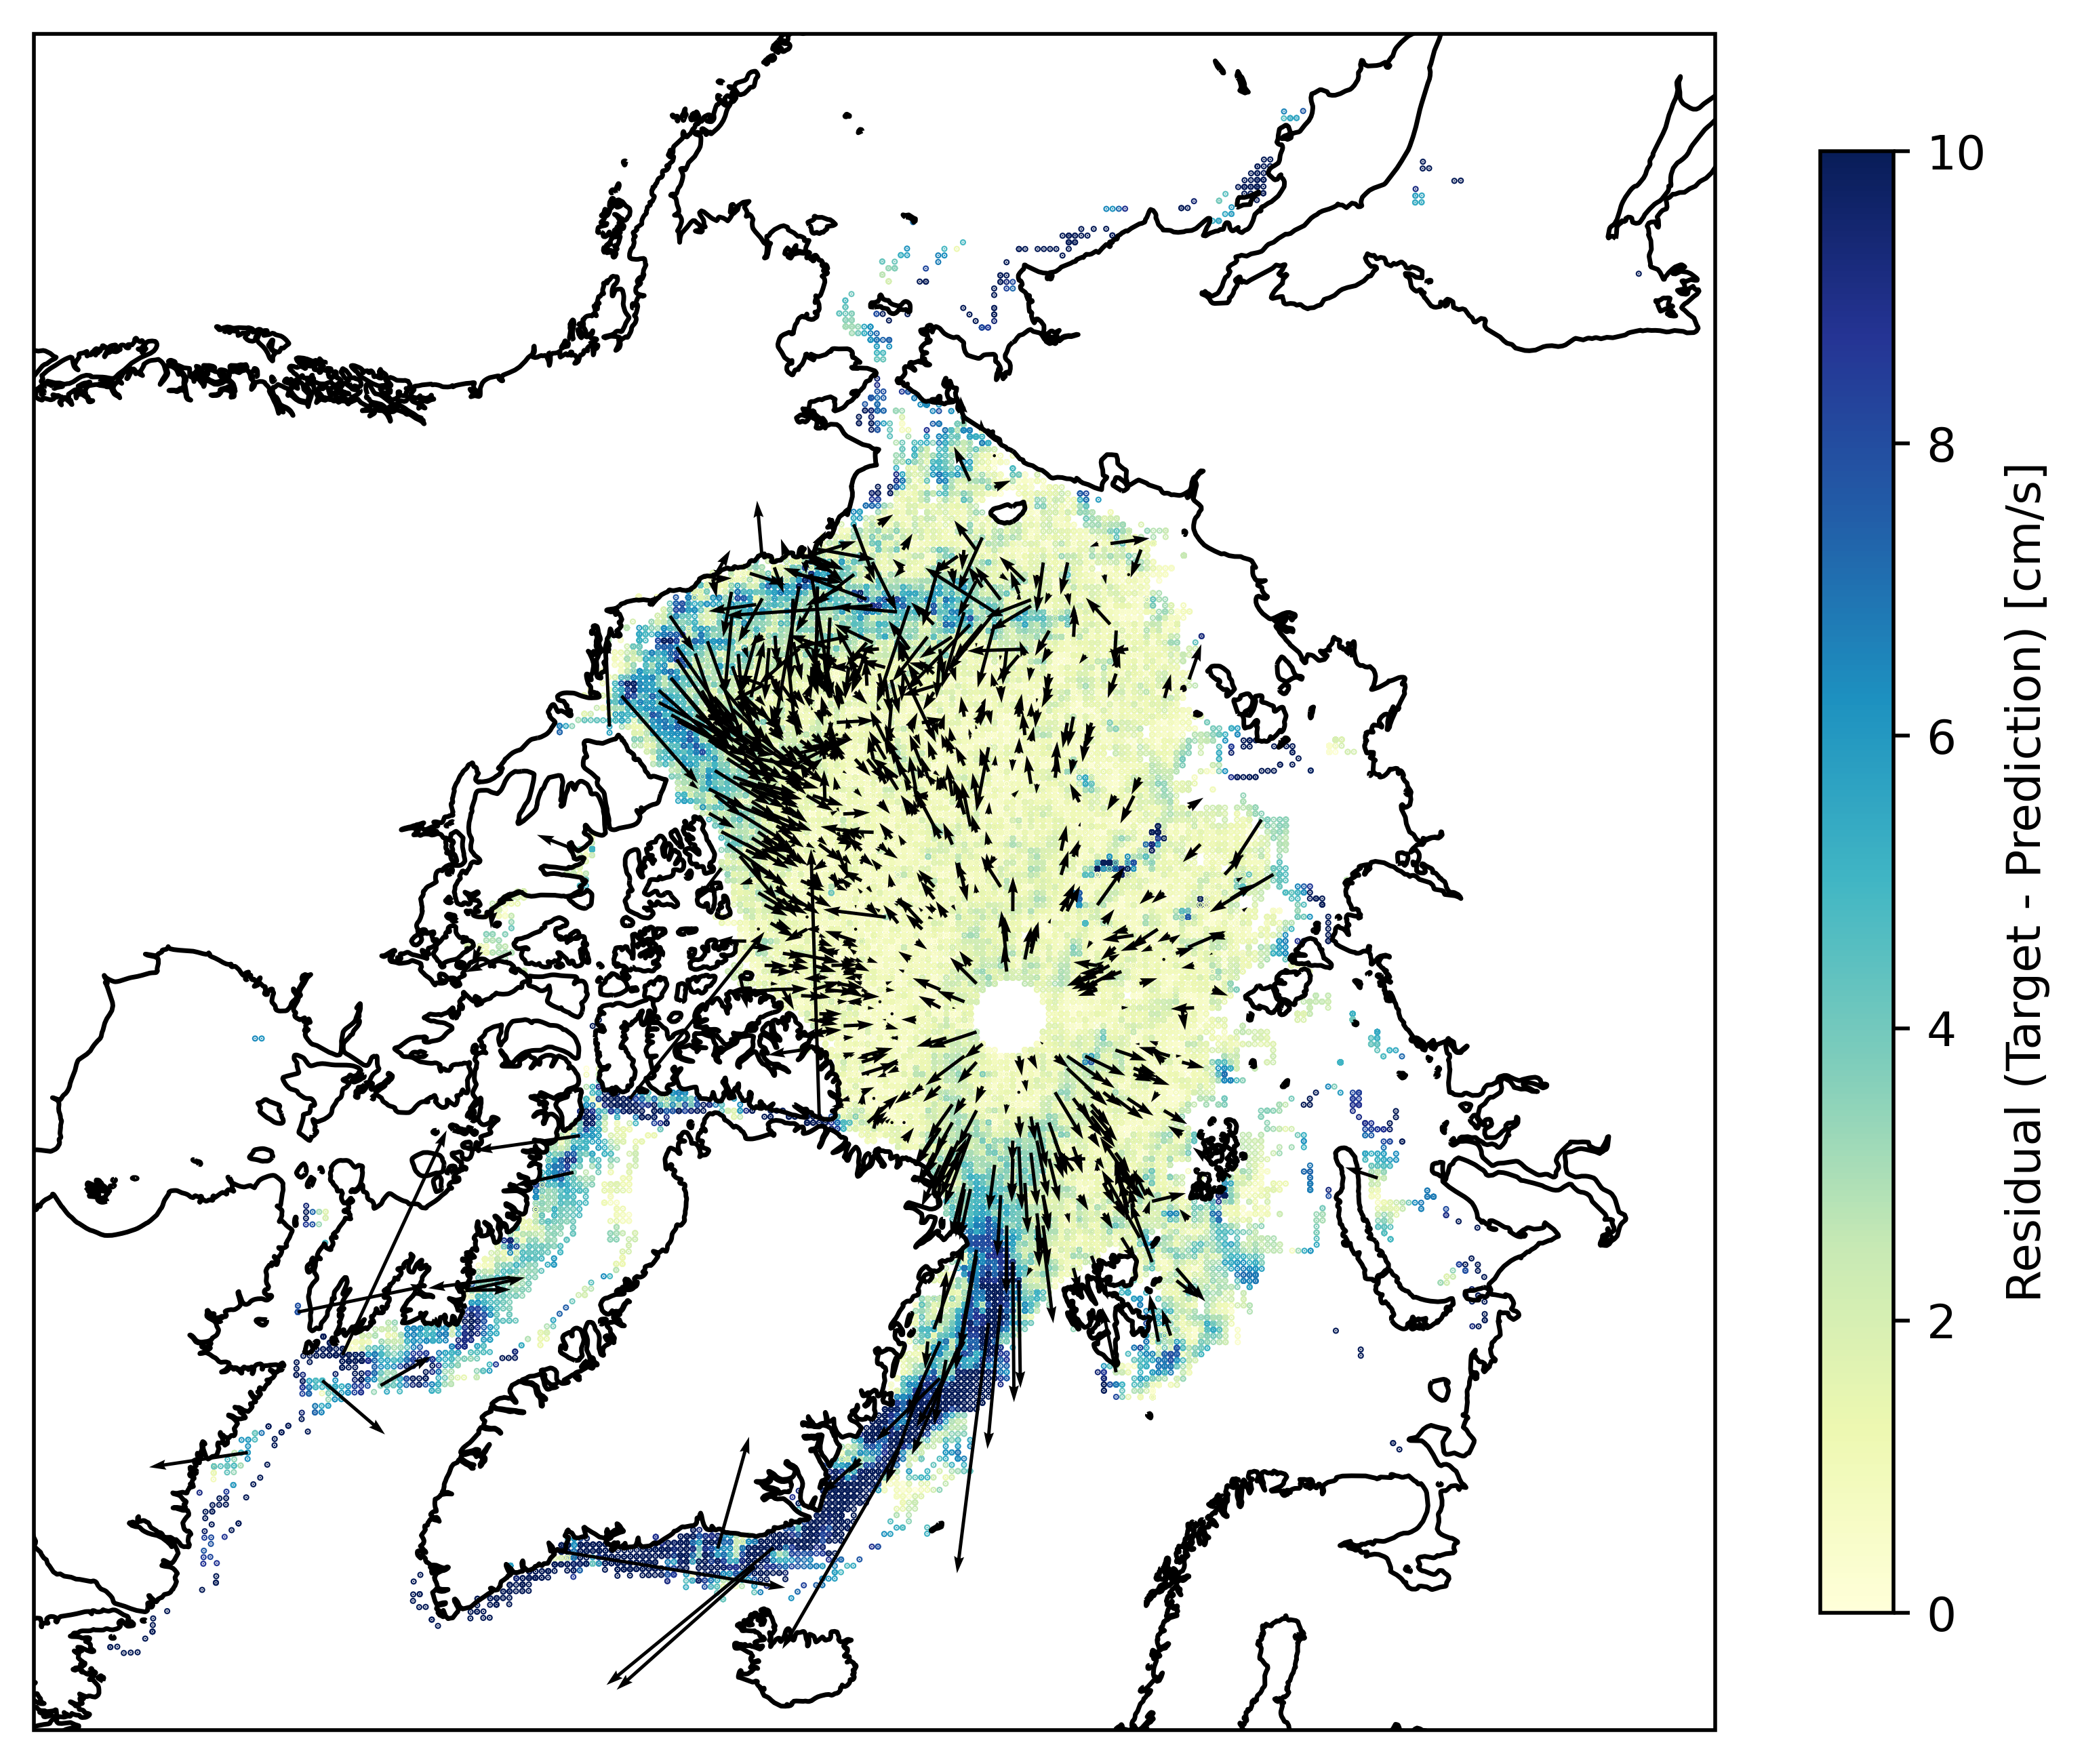

In [10]:
u=testdata['u_geo']
v=testdata['v_geo']
speed=np.sqrt(u**2+v**2)
step=500
fig, ax = plt.subplots(

    figsize=(8, 8),
    dpi=500,
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

vmin,vmax=0,10
norm = Normalize(vmin, vmax)
cmap = 'YlGnBu'
ax.coastlines()


back= ax.scatter(
    lons, lats,
        c=speed, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        s=.1
)
plt.colorbar(back, ax=ax, label='Residual (Target - Prediction) [cm/s]', shrink=0.7)

ax.quiver(
    lons[::step],lats[::step],
    u[::step],-v[::step],
    transform=ccrs.PlateCarree(),
    scale=100.0,         # adjust to get arrow lengths that make sense
    width=0.002,
)



In [35]:
# def lowpassFilter(L):
#     """Given the parameters set above (k2,kmax),
#     this function takes in a 2D array and returns a lowpass filtered version of the array """
#     Lhat= fft.fft2(L) # fourrier tranforms the array

#     Lhat[k2>kmax]=0 # set the amplitude of all coefficients with |k| > kmax i.e. filters features that are smaller than 4 delx

#     L=fft.ifft2(Lhat).real # back to real space

#     return L

import pandas as pd
import cartopy.crs as ccrs 
from matplotlib.colors import Normalize
# Load the EASE grid lat/lon (only needs to happen once)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

ures=testdata['u_buoy'].values - testdata['u_out'].values
vres=testdata['v_buoy'].values - testdata['v_out'].values

print(lat_grid.shape)
import scipy.fft as fft
import xarray as xr
y=np.arange(lat_grid.shape[0]),
x=np.arange(lat_grid.shape[1])
uwater=xr.DataArray(
    {
        'u':(['y','x'], ures),
        'v':(['y','x'], -vres)

     },

     coords={
         'y': y,
         'x': x,
        'lat': (['y', 'x'], lat_grid),
        'lon': (['y', 'x'], lon_grid),
     }

)


(361, 361)


ValueError: Tuple (array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176

(361,)


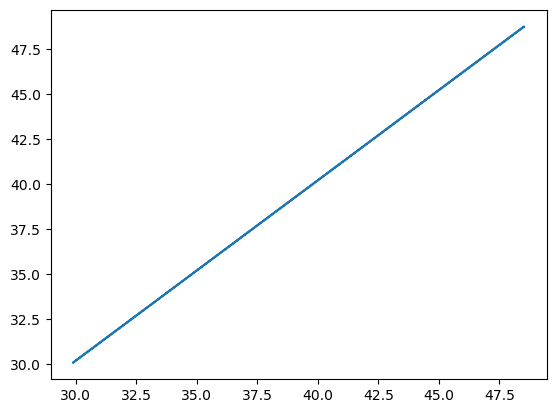

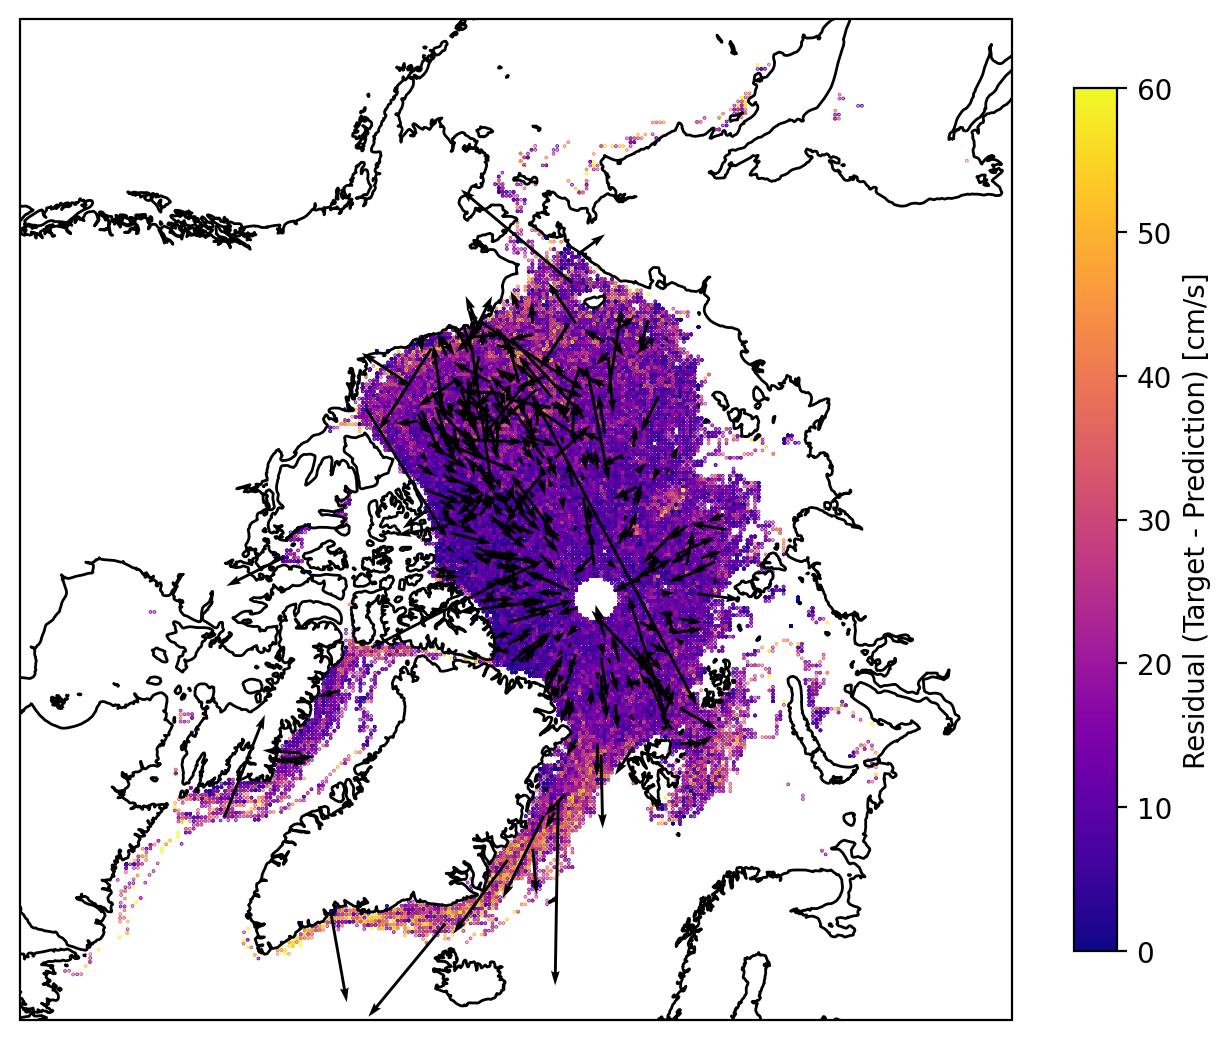

In [ ]:
import pandas as pd
import cartopy.crs as ccrs 
from matplotlib.colors import Normalize
# Load the EASE grid lat/lon (only needs to happen once)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

ures=testdata['u_buoy'].values - testdata['u_out'].values
vres=testdata['v_buoy'].values - testdata['v_out'].values

u_water = np.mean

fig, ax = plt.subplots(
    figsize=(8, 8),
    dpi=200,
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

vmin,vmax=0,60
norm = Normalize(vmin, vmax)
cmap = 'plasma'

ax.coastlines()
back= ax.scatter(
    lons, lats,
        c=testdata['buoynorm'], cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        s=.1
)
plt.colorbar(back, ax=ax, label='Residual (Target - Prediction) [cm/s]', shrink=0.7)

step=1000

ax.quiver(lons[::step],lats[::step],
          ures[::step],-vres[::step],
          transform=ccrs.PlateCarree())

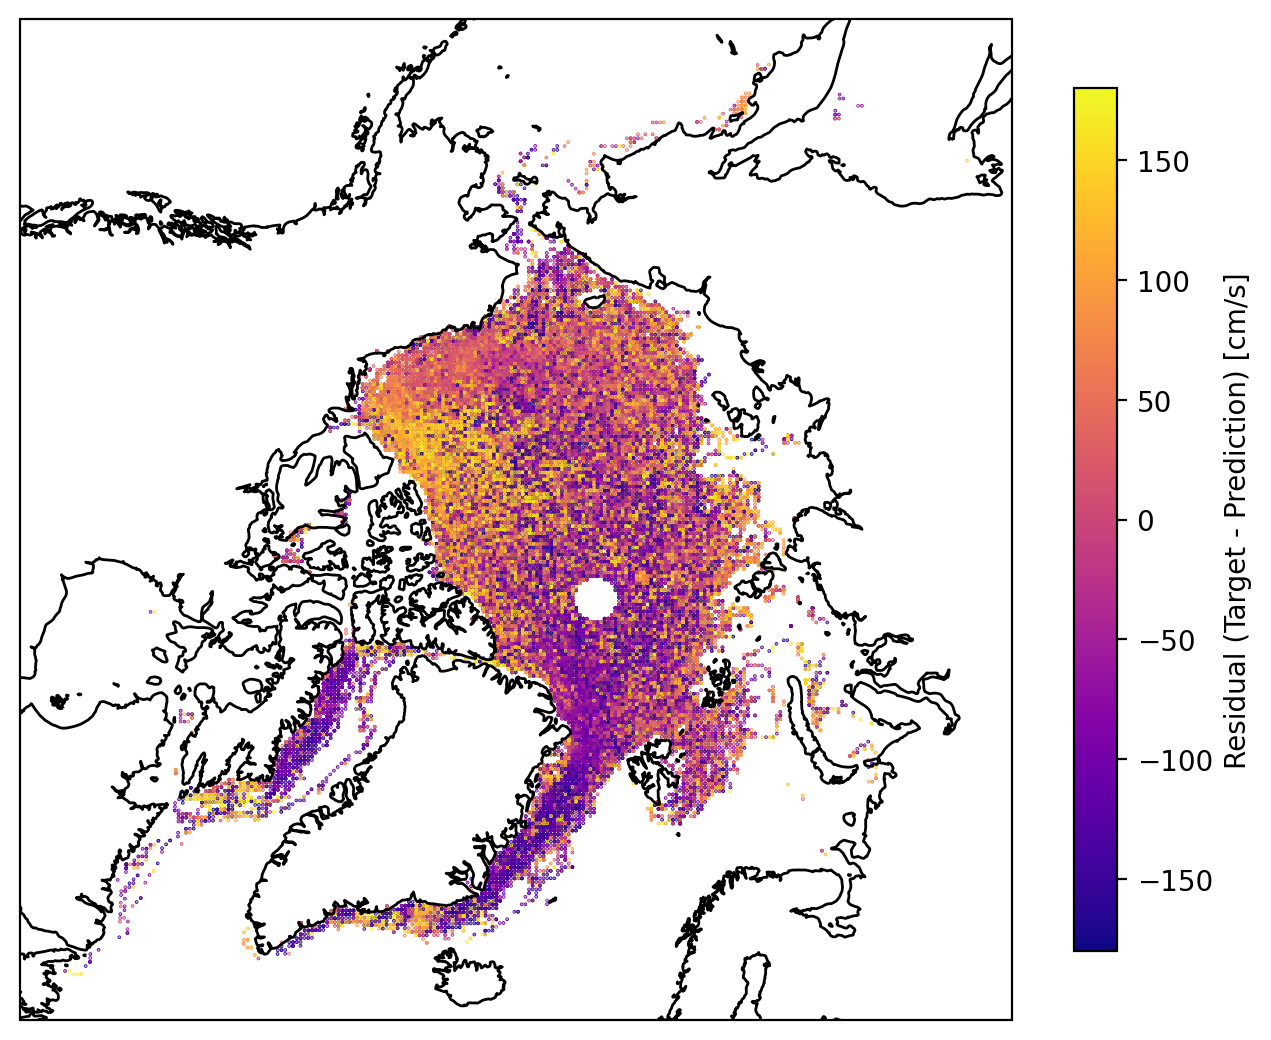

In [29]:
residual_angle = np.degrees(np.arctan2(-vres,ures))


import pandas as pd
import cartopy.crs as ccrs 
from matplotlib.colors import Normalize
# Load the EASE grid lat/lon (only needs to happen once)
lat_grid = pd.read_csv('../data/latitude_EASE.csv', header=None).values
lon_grid = pd.read_csv('../data/longitude_EASE.csv', header=None).values

# Convert your x,y grid indices to lat/lon for each sample
# (assumes data['x'], data['y'] are integer row/col indices into the grid)
lats = lat_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]
lons = lon_grid[testdata['y_EASE'].astype(int), testdata['x_EASE'].astype(int)]

fig, ax = plt.subplots(
    figsize=(8, 8),
    dpi=200,
    subplot_kw={'projection': ccrs.NorthPolarStereo()}
)

vmin,vmax=-180,180
norm = Normalize(vmin, vmax)
cmap = 'plasma'

ax.coastlines()
back= ax.scatter(
    lons, lats,
        c=residual_angle, cmap=cmap, norm=norm,
        transform=ccrs.PlateCarree(),
        s=.1
)
plt.colorbar(back, ax=ax, label='Residual (Target - Prediction) [cm/s]', shrink=0.7)